# Multiclass Classification for Bank Marketing

Building a multiclass classification model using PyTorch. We will use the ["Bank Marketing" dataset from OpenML (ID: 1461)](https://www.openml.org/search?type=data&status=active&id=1461&sort=runs).

The goal is to predict whether a client will subscribe to a term deposit (`y` variable).

The notebook will cover the following steps:
1. **Data Loading and Exploration**: Fetching the dataset and understanding its properties through descriptions and visualizations.
2. **Data Preprocessing**: Handling categorical and numerical features to prepare the data for the model.
3. **Model Building & Training**: Defining a neural network in PyTorch and training it.
4. **Evaluation**: Assessing the model's performance on the test set.
5. **Saving and Loading**: Persisting the model and preprocessors for future use.
6. **Inference**: Using the loaded model to make predictions on new, unseen data.

In [1]:
import openml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

# Settings
sns.set(style="whitegrid")
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Data Loading and Exploration

In [21]:
dataset = openml.datasets.get_dataset(1461)  # Bank Marketing dataset
X, y_original, categorical_indicator, feature_names = dataset.get_data(
    dataset_format="dataframe", target=dataset.default_target_attribute
)

# The user wants to predict 'V16' (poutcome) instead of the original 'y' target.
y = X.pop('V16') # Use V16 as target and remove it from features.

print(dataset.description)

**Author**: Paulo Cortez, Sérgio Moro

**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/bank+marketing)

**Please cite**: S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology. In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, Guimarães, Portugal, October, 2011. EUROSIS.       



**Bank Marketing**  

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be (or not) subscribed. 



The classification goal is to predict if the client will subscribe a term deposit (variable y).



### Attribute information  

For more information, read [Moro et al., 2011].



Input variables:



- bank client data:



1 - age (numeric) 



2 - job : type o

In [22]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nFirst 5 rows of X:\n", X.head())

Shape of X: (45211, 15)
Shape of y: (45211,)

First 5 rows of X:
    V1            V2       V3         V4  V5      V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143.0  yes   no  unknown    5   
1  44    technician   single  secondary  no    29.0  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2.0  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506.0  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1.0   no   no  unknown    5   

   V11    V12  V13  V14  V15  
0  may  261.0    1 -1.0  0.0  
1  may  151.0    1 -1.0  0.0  
2  may   76.0    1 -1.0  0.0  
3  may   92.0    1 -1.0  0.0  
4  may  198.0    1 -1.0  0.0  


In [23]:
print(y.value_counts())

V16
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


### Target Variable Distribution
Let's examine the distribution of our target variable, 'y'.

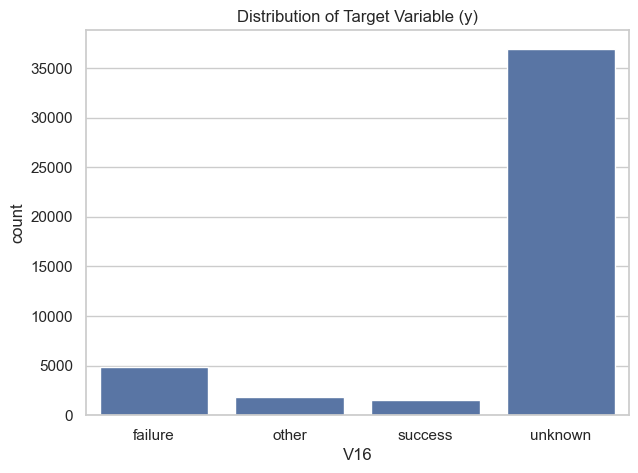

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(x=y)
plt.title('Distribution of Target Variable (y)')
plt.show()

The dataset is imbalanced, with many more 'no' (1) than 'yes' (2) responses. For this demonstration, we will proceed, but in a real-world scenario, techniques like over-sampling (e.g., SMOTE) or using class weights would be important.

### Feature Analysis

In [25]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['V1', 'V6', 'V10', 'V12', 'V13', 'V14', 'V15']

Categorical features: ['V2', 'V3', 'V4', 'V5', 'V7', 'V8', 'V9', 'V11']


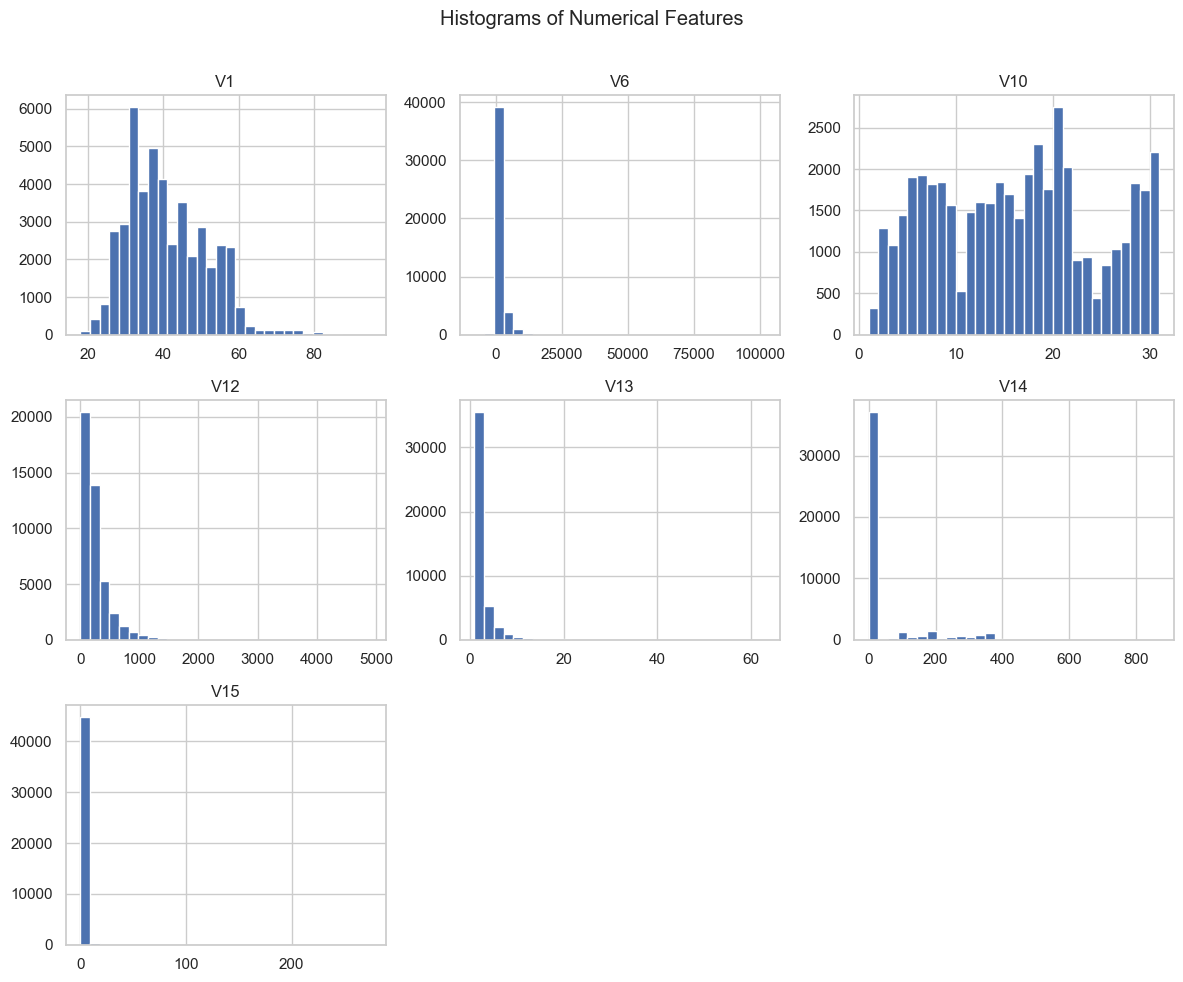

In [26]:
# Histograms for numerical features
X[numerical_features].hist(figsize=(12, 10), bins=30)
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. Data Preprocessing

We need to convert our raw data into a format suitable for a neural network:
1.  **Categorical Features**: Convert to numerical format using one-hot encoding.
2.  **Numerical Features**: Scale to have a mean of 0 and a standard deviation of 1.
3.  **Target Variable**: Convert string labels to integer labels.

In [27]:
# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Save the columns for later use in inference
encoded_columns = X_encoded.columns.tolist()

In [28]:
print("Shape of X after encoding:", X_encoded.shape)
print("\nFirst 5 rows of X after encoding:\n", X_encoded.head())
print("\nColumns after encoding:\n", encoded_columns)

Shape of X after encoding: (45211, 39)

First 5 rows of X after encoding:
    V1      V6  V10    V12  V13  V14  V15  V2_blue-collar  V2_entrepreneur  \
0  58  2143.0    5  261.0    1 -1.0  0.0           False            False   
1  44    29.0    5  151.0    1 -1.0  0.0           False            False   
2  33     2.0    5   76.0    1 -1.0  0.0           False             True   
3  47  1506.0    5   92.0    1 -1.0  0.0            True            False   
4  33     1.0    5  198.0    1 -1.0  0.0           False            False   

   V2_housemaid  ...  V11_dec  V11_feb  V11_jan  V11_jul  V11_jun  V11_mar  \
0         False  ...    False    False    False    False    False    False   
1         False  ...    False    False    False    False    False    False   
2         False  ...    False    False    False    False    False    False   
3         False  ...    False    False    False    False    False    False   
4         False  ...    False    False    False    False    False    Fal

In [29]:
# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Encoded y classes:", label_encoder.classes_)

Encoded y classes: ['failure' 'other' 'success' 'unknown']


In [30]:
# Split data before scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
) # stratify to maintain class distribution

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nTrain set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Train set shape: (36168, 39)
Test set shape: (9043, 39)


### Convert to PyTorch Tensors

In [31]:
X_train_t = torch.from_numpy(X_train.values.astype(np.float32))
y_train_t = torch.from_numpy(y_train).to(torch.long) # CrossEntropyLoss expects long
X_test_t = torch.from_numpy(X_test.values.astype(np.float32))
y_test_t = torch.from_numpy(y_test).to(torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

## 3. Model Building & Training

In [32]:
class BankNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_out = nn.Linear(32, num_classes)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(32)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.layer_1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.layer_2(x)))
        x = self.dropout(x)
        x = self.layer_out(x)
        return x

input_dim = X_train_t.shape[1]
num_classes = len(label_encoder.classes_)
model = BankNet(input_dim, num_classes)
print(model)

BankNet(
  (layer_1): Linear(in_features=39, out_features=64, bias=True)
  (layer_2): Linear(in_features=64, out_features=32, bias=True)
  (layer_out): Linear(in_features=32, out_features=4, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


In [33]:
criterion = nn.CrossEntropyLoss() # Combines LogSoftmax and NLLLoss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred_logits = model(batch_X)
        loss = criterion(y_pred_logits, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/20, Loss: 0.3196
Epoch 2/20, Loss: 0.1698
Epoch 3/20, Loss: 0.1613
Epoch 4/20, Loss: 0.1580
Epoch 5/20, Loss: 0.1569
Epoch 6/20, Loss: 0.1552
Epoch 7/20, Loss: 0.1536
Epoch 8/20, Loss: 0.1538
Epoch 9/20, Loss: 0.1523
Epoch 10/20, Loss: 0.1512
Epoch 11/20, Loss: 0.1507
Epoch 12/20, Loss: 0.1503
Epoch 13/20, Loss: 0.1478
Epoch 14/20, Loss: 0.1493
Epoch 15/20, Loss: 0.1483
Epoch 16/20, Loss: 0.1469
Epoch 17/20, Loss: 0.1464
Epoch 18/20, Loss: 0.1464
Epoch 19/20, Loss: 0.1458
Epoch 20/20, Loss: 0.1453


### Visualize Training Loss

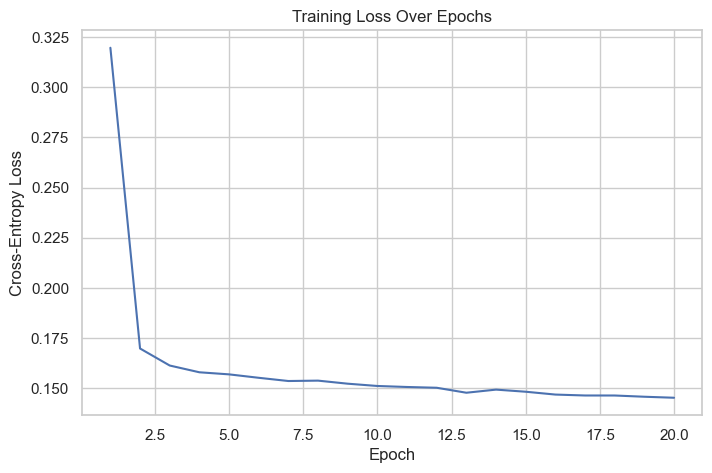

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.show()

## 4. Evaluation

In [35]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        y_pred_logits = model(batch_X)
        y_pred_labels = torch.argmax(y_pred_logits, dim=1)
        all_preds.extend(y_pred_labels.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9330


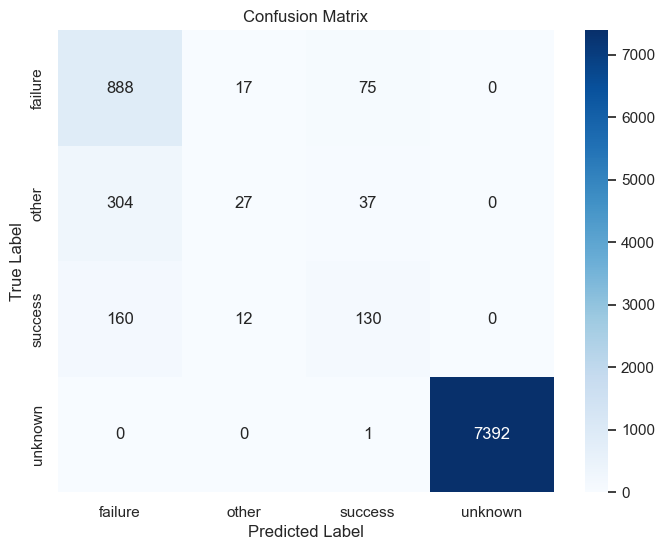


Classification Report:
               precision    recall  f1-score   support

     failure       0.66      0.91      0.76       980
       other       0.48      0.07      0.13       368
     success       0.53      0.43      0.48       302
     unknown       1.00      1.00      1.00      7393

    accuracy                           0.93      9043
   macro avg       0.67      0.60      0.59      9043
weighted avg       0.93      0.93      0.92      9043



In [36]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

## 5. Saving and Loading

We'll save the model's state dictionary, the scaler, the label encoder, and the list of encoded column names. 

These are all required to make predictions on new, raw data.

In [37]:
torch.save(model.state_dict(), "bank_model.pth")
joblib.dump(scaler, "bank_scaler.pkl")
joblib.dump(label_encoder, "bank_label_encoder.pkl")
joblib.dump(encoded_columns, "bank_encoded_columns.pkl")

print("Model and preprocessing artifacts saved successfully.")

Model and preprocessing artifacts saved successfully.


## 6. Inference

This section simulates a real-world scenario where you load your saved model to make predictions on new data.

In [38]:
# Load the artifacts
loaded_model = BankNet(input_dim, num_classes)
loaded_model.load_state_dict(torch.load("bank_model.pth"))
loaded_model.eval()

loaded_scaler = joblib.load("bank_scaler.pkl")
loaded_label_encoder = joblib.load("bank_label_encoder.pkl")
loaded_encoded_columns = joblib.load("bank_encoded_columns.pkl")

print("Artifacts loaded for inference.")

Artifacts loaded for inference.


### Prepare New Data and Predict

In [41]:
# Create a new data point as a DataFrame (must match original structure)
new_data = pd.DataFrame([
    {'V1': 30, 'V2': 'unemployed', 'V3': 'married', 'V4': 'primary', 'V5': 'no', 
     'V6': 1787, 'V7': 'no', 'V8': 'no', 'V9': 'cellular', 'V10': 19, 'V11': 'oct', 
     'V12': 79, 'V13': 1, 'V14': -1, 'V15': 0},
    {'V1': 55, 'V2': 'services', 'V3': 'married', 'V4': 'secondary', 'V5': 'no', 
     'V6': 2500, 'V7': 'yes', 'V8': 'no', 'V9': 'cellular', 'V10': 5, 'V11': 'may', 
     'V12': 300, 'V13': 2, 'V14': -1, 'V15': 0}
])

## Preprocess the new data

In [43]:
categorical_features

['V2', 'V3', 'V4', 'V5', 'V7', 'V8', 'V9', 'V11']

In [42]:

# 1. One-hot encode
new_data_encoded = pd.get_dummies(new_data, columns=categorical_features, drop_first=True)

# 2. Align columns with the training data
new_data_aligned = new_data_encoded.reindex(columns=loaded_encoded_columns, fill_value=0)

# 3. Scale numerical features
new_data_aligned[numerical_features] = loaded_scaler.transform(new_data_aligned[numerical_features])

# 4. Convert to tensor
new_data_t = torch.from_numpy(new_data_aligned.values.astype(np.float32))

# Make prediction
with torch.no_grad():
    pred_logits = loaded_model(new_data_t)
    pred_labels = torch.argmax(pred_logits, dim=1).numpy()

# Decode labels to original class names
pred_class_names = loaded_label_encoder.inverse_transform(pred_labels)

print("Predictions for new data:")
for i, prediction in enumerate(pred_class_names):
    print(f"Data point {i+1}: Predicted outcome = {prediction}")

Predictions for new data:
Data point 1: Predicted outcome = unknown
Data point 2: Predicted outcome = unknown
